In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## Loading the datasets

orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")

In [ ]:
## Inspecting the data

orders.head()
# orders.info()
# reviews.head()
# customers.head()
# products.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
## Converting the date columns

orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [ ]:
## Filtering the delivered orders

orders = orders[orders['order_status'] == 'delivered']
orders['order_status'].value_counts()

,count
order_status,
delivered,96478


In [ ]:
## Removing duplicates

reviews = reviews.drop_duplicates(subset='order_id')

In [ ]:
## Joining Orders and Reviews

orders_reviews = pd.merge(
    orders,
    reviews,
    on='order_id',
    how='left'
)
orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [ ]:
## Joining the Customer table with the Orders_reviews

master_data = pd.merge(
    orders_reviews,
    customers,
    on='customer_id',
    how='left'
)
master_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
## Checking for missing Review scores

master_data['review_score'].isnull().sum()

np.int64(646)

In [ ]:
## Calculating the delivery delay

master_data['days_difference'] = (
    master_data['order_delivered_customer_date'] -
    master_data['order_estimated_delivery_date']
).dt.days
# master_data.head()

In [ ]:
## Classifying the delivery status(on Time, Late and Super Late)

def classify_delivery(days):

    if days <= 0:
        return "On Time"

    elif days <= 5:
        return "Late"

    else:
        return "Super Late"



In [ ]:
## Applying the classifying function and then verifying it

master_data['delivery_status'] = master_data['days_difference'].apply(classify_delivery)
# master_data.head()
master_data['delivery_status'].value_counts()

,count
delivery_status,
On Time,89936
Super Late,3772
Late,2770


In [ ]:
## Counting the total orders per state

state_total_orders = master_data.groupby('customer_state').size()
state_total_orders.head()

,0
customer_state,
AC,80
AL,397
AM,145
AP,67
BA,3256


In [ ]:
## Counting Late orders per state(ie. late and super late)

late_orders = master_data[
    master_data['delivery_status'] != "On Time"
]

late_by_state = late_orders.groupby('customer_state').size()
late_by_state.head()

,0
customer_state,
AC,3
AL,85
AM,4
AP,2
BA,396


In [ ]:
## Building comparison table

state_analysis = pd.DataFrame({
    'total_orders': state_total_orders,
    'late_orders': late_by_state
})

state_analysis.head()

,total_orders,late_orders
customer_state,,
AC,80,3
AL,397,85
AM,145,4
AP,67,2
BA,3256,396


In [ ]:
## Calculating the late percentage

state_analysis['late_percentage'] = (
    state_analysis['late_orders'] /
    state_analysis['total_orders']
) * 100

state_analysis['late_percentage'] = state_analysis['late_percentage'].round(2)
state_analysis = state_analysis.fillna(0)

In [ ]:
## Sorting the results(worst_performing state)


state_analysis = state_analysis.sort_values(
    by='late_percentage',
    ascending=False
)

In [ ]:
## Inspecting the results

state_analysis.head(10)

,total_orders,late_orders,late_percentage
customer_state,,,
AL,397,85,21.41
MA,717,125,17.43
SE,335,51,15.22
PI,476,66,13.87
CE,1279,176,13.76
RR,41,5,12.20
BA,3256,396,12.16
RJ,12350,1495,12.11
PA,946,106,11.21


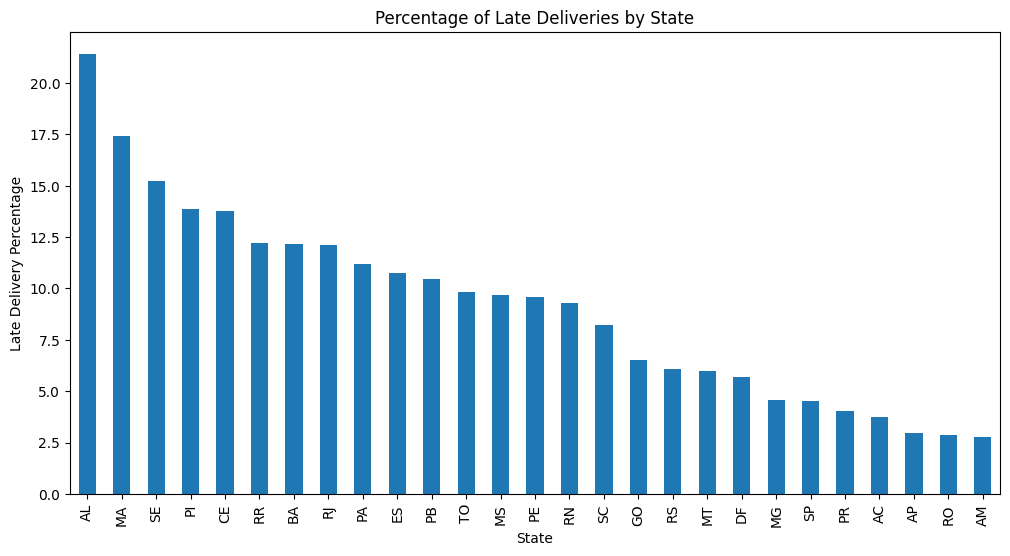

In [ ]:
## Creating a Visulization(using matplotlib)


state_analysis['late_percentage'].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Percentage of Late Deliveries by State")
plt.xlabel("State")
plt.ylabel("Late Delivery Percentage")
plt.show()

In [ ]:
## Checking if Review score exit in my data


master_data['review_score'].head()

,review_score
0,4.0
1,4.0
2,5.0
3,5.0
4,5.0


In [ ]:
## Calculating the Average Review Score by the delivery status

review_analysis = master_data.groupby('delivery_status')['review_score'].mean()

review_analysis = review_analysis.reset_index()
review_analysis.round(2)

,delivery_status,review_score
0,Late,2.99
1,On Time,4.29
2,Super Late,1.74


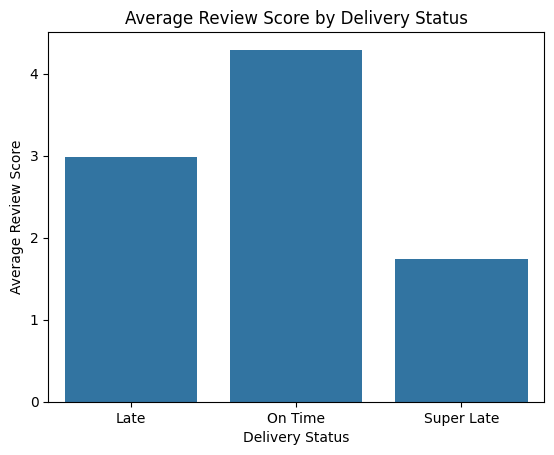

In [ ]:
## Creating a visualization(bar chart)


sns.barplot(
    data=review_analysis,
    x='delivery_status',
    y='review_score'
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.show()

In [ ]:
## Calculating the correlation between delay days and review score
## (negative correlaton shows more delay => lower review score)

master_data[['days_difference','review_score']].corr()

,days_difference,review_score
days_difference,1.000000,-0.267263
review_score,-0.267263,1.000000


In [ ]:
# order_items = pd.read_csv("olist_order_items_dataset.csv")

In [ ]:
master_data = pd.merge(
    master_data,
    order_items[['order_id', 'product_id']],
    on='order_id',
    how='left'
)
master_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,days_difference,delivery_status,product_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-8.0,On Time,87285b34884572647811a353c7ac498a
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,...,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-6.0,On Time,595fac2a385ac33a80bd5114aec74eb8
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-18.0,On Time,aa4383b373c6aca5d8797843e5594415
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-13.0,On Time,d0b61bfb1de832b15ba9d266ca96e5b0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,...,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-10.0,On Time,65266b2da20d04dbe00c5c2d3bb7859e


In [ ]:
## Now we do the Language Translation
## Merging the products table with the master data


master_data = pd.merge(
    master_data,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

In [ ]:
## Merging the English translator

master_data = pd.merge(
    master_data,
    translation,
    left_on='product_category_name',
    right_on='product_category_name',
    how='left'
)

In [ ]:
## Renaming the translation column for clarity

master_data.rename(
    columns={'product_category_name_english': 'category_english'},
    inplace=True
)
master_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,days_difference,delivery_status,product_id,product_category_name,category_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,...,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-8.0,On Time,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,...,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,-6.0,On Time,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,...,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,-18.0,On Time,aa4383b373c6aca5d8797843e5594415,automotivo,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,...,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,-13.0,On Time,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,...,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-10.0,On Time,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery


In [ ]:
## The Challenge aspect
## Calculating the average delay by product category

category_analysis = master_data.groupby('category_english')['days_difference'].mean().reset_index()
category_analysis = category_analysis.sort_values(by='days_difference', ascending=False)

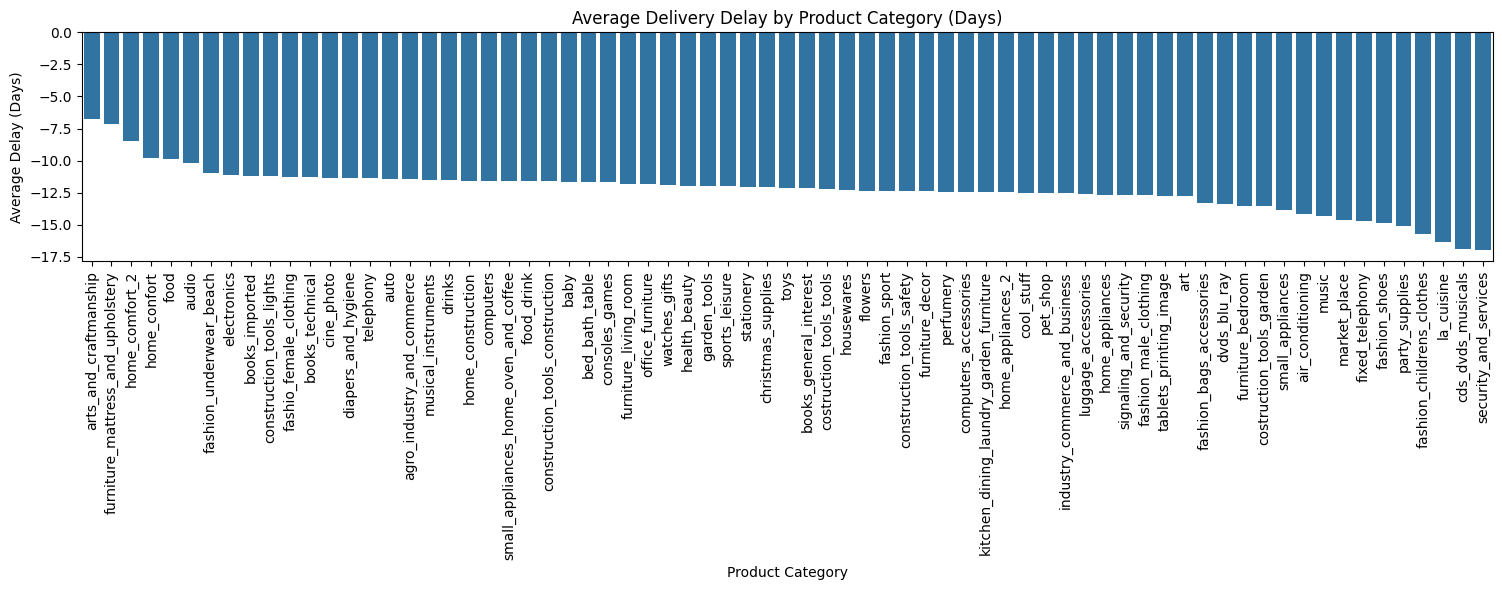

In [ ]:
## Visulizing the product display


plt.figure(figsize=(15,6))
sns.barplot(
    data=category_analysis,
    x='category_english',
    y='days_difference'
)
plt.xticks(rotation=90)  # vertical labels
plt.title("Average Delivery Delay by Product Category (Days)")
plt.xlabel("Product Category")
plt.ylabel("Average Delay (Days)")
plt.tight_layout()  # prevent label cutoff
plt.show()

In [ ]:
## Downloading the master data

# master_data.to_csv("final_dashboard_dataset.csv", index=False)